In [4]:
import xarray as xr

# Load predictions
predictions = xr.open_dataset("../example_loamy_raid", engine="zarr")

# Load ground truth
ground_truth = xr.open_dataset("../data/datastore.interior.domain03.zarr", engine="zarr")



/tmp/ipykernel_858272/3149368347.py:4: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  predictions = xr.open_dataset("../example_loamy_raid", engine="zarr")


In [5]:
def combine_state_features(ds):
    """
    Combine individual state features from an xarray.Dataset into a single dataset.

    Parameters:
    ds (xarray.Dataset): The input dataset containing state features.

    Returns:
    xarray.Dataset: A new dataset with each state feature as a separate variable.
    """
    # Create a new dataset to hold the combined features
    combined_ds = xr.Dataset()

    # Loop through each state feature and add it to the combined dataset
    for feature in ds.state_feature.values:
        individual_array = ds.state.sel(state_feature=feature)
        combined_ds[feature] = individual_array

    return combined_ds

In [6]:
combined_predictions = combine_state_features(predictions)
combined_ground_truth = combine_state_features(ground_truth)

In [7]:
combined_predictions

<xarray.Dataset> Size: 159GB
Dimensions:                    (elapsed_forecast_duration: 12,
                                grid_index: 524288, start_time: 1052)
Coordinates:
  * elapsed_forecast_duration  (elapsed_forecast_duration) timedelta64[ns] 96B ...
  * grid_index                 (grid_index) int64 4MB 11255161 ... 3934314
  * start_time                 (start_time) datetime64[ns] 8kB 2020-02-12T00:...
    state_feature              <U8 32B 't_2m'
    time                       (elapsed_forecast_duration) datetime64[ns] 96B ...
Data variables:
    t_2m                       (start_time, elapsed_forecast_duration, grid_index) float32 26GB ...
    u_10m                      (start_time, elapsed_forecast_duration, grid_index) float32 26GB ...
    v_10m                      (start_time, elapsed_forecast_duration, grid_index) float32 26GB ...
    pres_sfc                   (start_time, elapsed_forecast_duration, grid_index) float32 26GB ...
    qv_2m                      (start_time, elapsed_forecast_duration, grid_index) float32 26GB ...
    tqc_dia                    (start_time, elapsed_forecast_duration, grid_index) float32 26GB ...

In [8]:
combined_ground_truth

<xarray.Dataset> Size: 70GB
Dimensions:                       (grid_index: 524288, time: 5543)
Coordinates:
    clat                          (grid_index) float64 4MB ...
    clon                          (grid_index) float64 4MB ...
  * grid_index                    (grid_index) int64 4MB 11255161 ... 3934314
    state_feature                 <U8 32B 't_2m'
    state_feature_long_name       <U48 192B ...
    state_feature_source_dataset  <U11 44B ...
    state_feature_units           <U8 32B ...
  * time                          (time) datetime64[ns] 44kB 2020-01-11T22:20...
Data variables:
    t_2m                          (time, grid_index) float32 12GB ...
    u_10m                         (time, grid_index) float32 12GB ...
    v_10m                         (time, grid_index) float32 12GB ...
    pres_sfc                      (time, grid_index) float32 12GB ...
    qv_2m                         (time, grid_index) float32 12GB ...
    tqc_dia                       (time, grid_index) float32 12GB ...

In [ ]:
da_prediction = combined_predictions.t_2m.sel(start_time="2020-02-18T15:00:00").isel(elapsed_forecast_duration=slice(0,-1, 3)) # "2020-02-12T15:00:00" (flower-ish); "2020-02-18T15:00:00" (sugar-ish in a eastern domain)
prediction_times = da_prediction.start_time.values + da_prediction.elapsed_forecast_duration.values
da_target = combined_ground_truth.t_2m.sel(time=prediction_times)

assert da_target.time.shape == da_prediction.elapsed_forecast_duration.shape

vmin = min(da_prediction.min(), da_target.min())
vmax = max(da_prediction.max(), da_target.max())

In [20]:
prediction_times

array(['2020-02-18T15:10:00.000000000', '2020-02-18T15:40:00.000000000',
       '2020-02-18T16:10:00.000000000', '2020-02-18T16:40:00.000000000'],
      dtype='datetime64[ns]')

/tmp/ipykernel_858272/1860252321.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


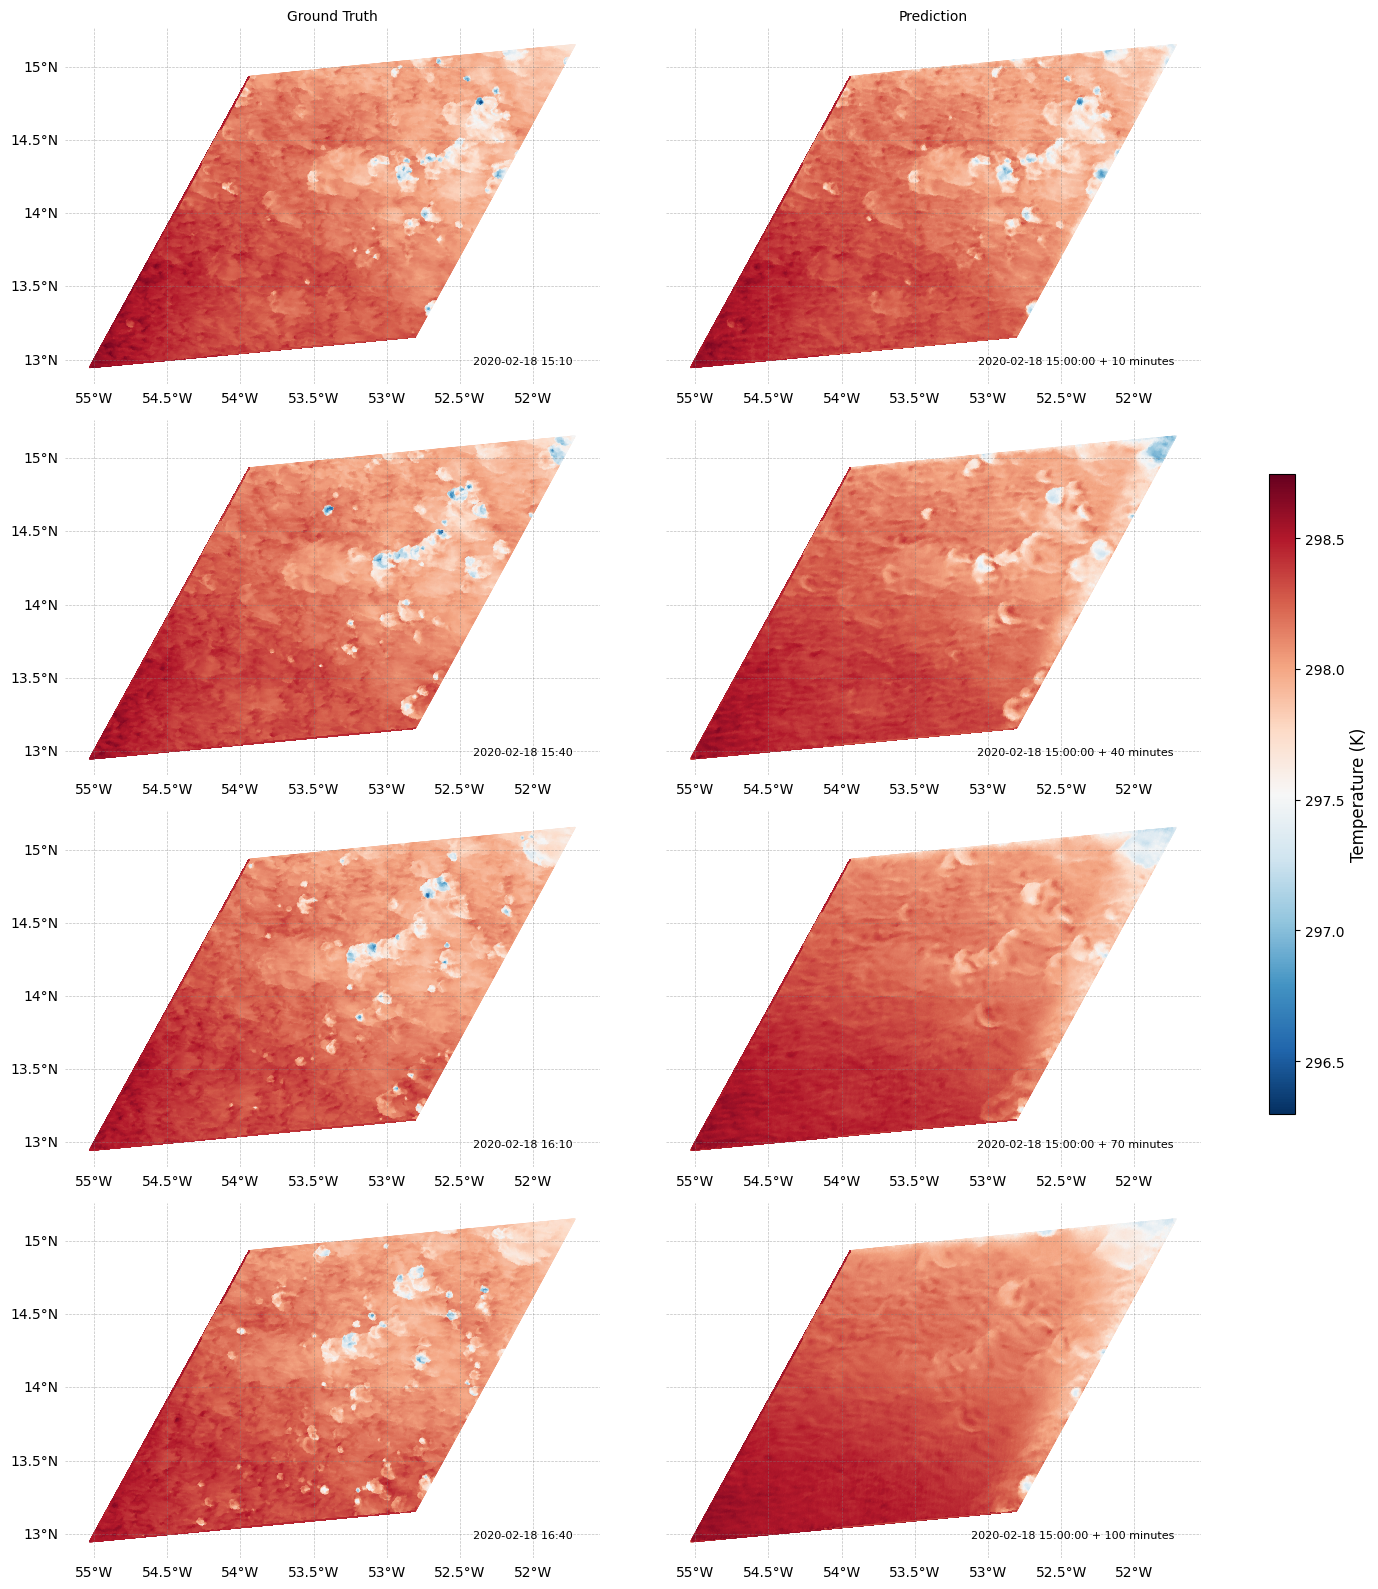

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import pandas as pd

# Extract the temporal dimension
time_steps = da_target.time.values

# Create subplots for each time step
fig, axes = plt.subplots(
    len(time_steps),
    2,
    figsize=(13, 4 * len(time_steps)),
    subplot_kw={"projection": ccrs.PlateCarree()},
)

# Ensure axes is a 2D array for consistent indexing
if len(time_steps) == 1:
    axes = np.array([axes])

# Plot for each time step
for i, time_step in enumerate(time_steps):
    da_target_time = da_target.isel(time=i)
    da_prediction_time = da_prediction.isel(elapsed_forecast_duration=i)

    for ax, da, title in zip(axes[i], [da_target_time, da_prediction_time], ["Ground Truth", "Prediction"]):
        lons = np.rad2deg(da_target_time.clon)
        lats = np.rad2deg(da_target_time.clat)

        ax.tripcolor(
            lons,
            lats,
            da.values,
            shading="gouraud",
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
        )
        gl = ax.gridlines(
            linewidth=0.5,
            color="gray",
            alpha=0.5,
            linestyle="--",
            draw_labels=True,
        )
        gl.right_labels = False
        gl.top_labels = False
        if ax is axes[i, 1]:
            gl.left_labels = False

        ax.spines['geo'].set_visible(False)
        if i == 0:
            ax.set_title(f"{title}", size=10)
        
        if ax is axes[i, 0]:
            ax.annotate(
            pd.Timestamp(time_step).to_pydatetime().strftime('%Y-%m-%d %H:%M'),
            xy=(0.95, 0.05), 
            xycoords='axes fraction',
            fontsize=8,
            ha="right",
            va="bottom",
            )

        if ax is axes[i, 1]:
            ax.annotate(
            f"{da_prediction.start_time.dt.strftime('%Y-%m-%d %H:%M:%S').values.item()} + {int(da_prediction.elapsed_forecast_duration.values[i].astype('timedelta64[m]').item().total_seconds() / 60)} minutes",
            xy=(0.95, 0.05), 
            xycoords='axes fraction',
            fontsize=8,
            ha="right",
            va="bottom",
            )

# Add a single colorbar for the entire figure
cbar_ax = fig.add_axes([1., 0.3, 0.02, 0.4])  # [left, bottom, width, height]
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label("Temperature (K)", size=12)

plt.tight_layout()